# ML: prediccion de pago tardio (al emitir la factura)

Tercer modelo ML, mismo patron honesto que `01_churn_model.ipynb`/`02_win_model.ipynb`. Pregunta del banco recibido por WhatsApp ("prediccion de pagos y mis pagos", ver `docs/decisiones.md` #27). Entrena un clasificador sobre `gold.fact_invoice` para predecir, **al momento de emitir la factura** (no al momento de pagar), si el pago llegara tarde o a tiempo. Sirve para que cobranza haga seguimiento proactivo a los clientes de mayor riesgo, antes de que se atrasen -- por eso la prediccion es al emitir, no al pagar (para cuando el pago ya paso, no hay nada que prevenir).

**Censura declarada:** se excluyen las facturas con `status = 'pending'` (10,048 de 50,000) -- todavia no vencieron, no sabemos si terminaran pagadas a tiempo, tarde, o en mora. Igual razonamiento que con las suscripciones `active` en el modelo de churn: incluirlas seria asumir un resultado que todavia no paso.

**Hallazgo de calidad de datos (nuevo, no documentado antes):** 3,533 de las 34,966 facturas `status = 'paid'` no tienen ninguna fila en `fact_payment` -- sin un pago asociado no se puede saber si llego a tiempo o tarde, asi que tambien se excluyen del entrenamiento (mismo criterio que `pending`: dato incompleto, no se asume un resultado). Documentado aca porque se descubrio construyendo este modelo -- se agrega a `docs/decisiones.md` #28.

## 1. Features -- y por que se excluyen otras

**Se usan:** `country`, `segment`, `is_student` (de `dim_customer` -- conocidos desde que el cliente existe), `total`, `days_to_due` (de `fact_invoice` -- conocidos al emitir la factura; `days_to_due` es el plazo de pago pactado -- ej. "neto 30" -- no cuanto tardo en pagar).

**Se excluyen a proposito:** cualquier columna de `fact_payment` (`method`, `days_to_pay`, `paid_date_id`) -- no existen todavia al momento de emitir la factura, serian informacion del futuro (fuga de datos). `status` de la factura tambien se excluye del set de features -- es basicamente el resultado que se quiere predecir.

In [1]:
import sys, os
sys.path.append("/home/jovyan/work/src")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

from utils.db import get_engine

engine = get_engine()
MODELS_ROOT = Path(os.environ.get("MODELS_ROOT", "/home/jovyan/work/models"))
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE = "#2a78d6", "#eb6834"

In [2]:
df = pd.read_sql("""
    WITH last_payment AS (
        SELECT invoice_id, MAX(paid_date_id) AS last_paid_date
        FROM gold.fact_payment
        GROUP BY invoice_id
    )
    SELECT
        (i.status = 'overdue' OR lp.last_paid_date > i.due_date_id) AS late,
        c.country, c.segment, c.is_student,
        i.total, i.days_to_due
    FROM gold.fact_invoice i
    JOIN gold.dim_customer c ON c.customer_id = i.customer_id
    LEFT JOIN last_payment lp ON lp.invoice_id = i.invoice_id
    WHERE i.status = 'overdue' OR (i.status = 'paid' AND lp.last_paid_date IS NOT NULL)
""", engine)

print("Filas:", len(df))
print("Balance de clases (late):")
print(df["late"].value_counts(normalize=True).round(3))

Filas: 36419
Balance de clases (late):
late
True     0.518
False    0.482
Name: proportion, dtype: float64


## 2. Split, pipeline y entrenamiento

`ColumnTransformer` con `OneHotEncoder` para categoricas y `StandardScaler` para numericas, dentro de un `Pipeline` con `RandomForestClassifier`. `class_weight="balanced"` por si `late` esta desbalanceada.

In [3]:
CATEGORICAL = ["country", "segment", "is_student"]
NUMERIC = ["total", "days_to_due"]

X = df[CATEGORICAL + NUMERIC]
y = df["late"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)),
])

pipeline.fit(X_train, y_train)
print("Entrenado.")

Entrenado.


## 3. Evaluacion

              precision    recall  f1-score   support

    a_tiempo       0.81      0.76      0.78      3511
      tardio       0.79      0.83      0.81      3773

    accuracy                           0.80      7284
   macro avg       0.80      0.80      0.80      7284
weighted avg       0.80      0.80      0.80      7284

ROC-AUC: 0.862


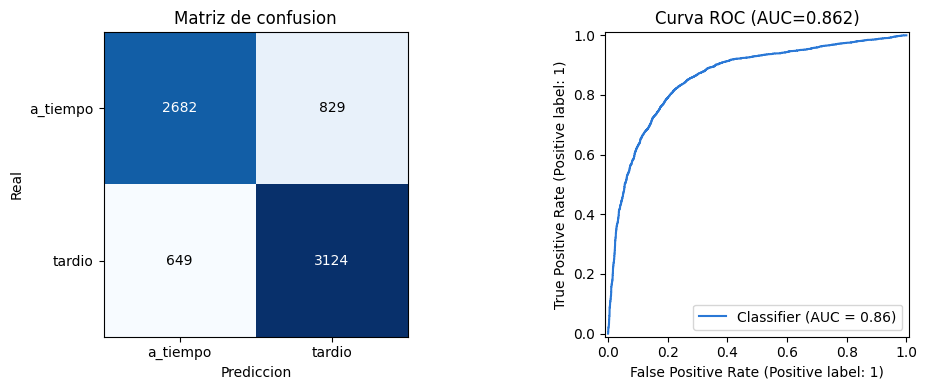

In [4]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["a_tiempo", "tardio"]))
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["a_tiempo", "tardio"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["a_tiempo", "tardio"])
axes[0].set_xlabel("Prediccion"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de confusion")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=BLUE)
axes[1].set_title(f"Curva ROC (AUC={auc:.3f})")
plt.tight_layout()
plt.show()

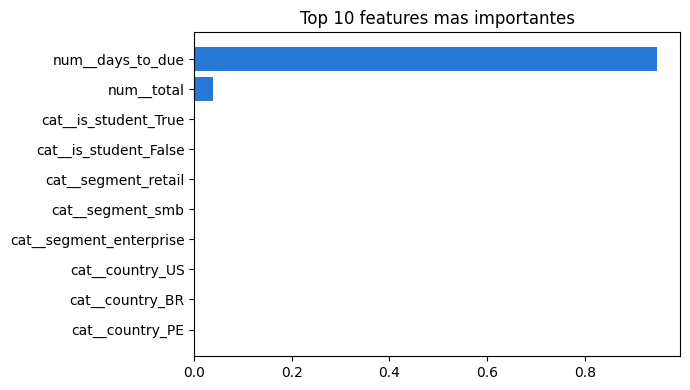

In [5]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_
imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp["feature"], imp["importance"], color=BLUE)
ax.set_title("Top 10 features mas importantes")
plt.tight_layout()
plt.show()

## 3.1 Hallazgo: a diferencia de churn/win, aca SI hay senal real -- pero no es la que se esperaba

**ROC-AUC = 0.862** (vs. ~0.51 en churn/win) -- muy por encima del azar, con `precision`/`recall` ~0.80 en ambas clases. Pero la importancia de features es contundente: **`days_to_due` explica el 94.8% de la prediccion** (`total` otro 3.9%; `country`/`segment`/`is_student` juntas no llegan al 1%).

Verificado agrupando `late` por `days_to_due` directo en Postgres: facturas con plazo de pago corto (`days_to_due = 7`) llegan tarde el **94.1%** de las veces; con plazo largo (`days_to_due = 59`) solo el **11.5%**. La relacion es casi monotonica y explica prácticamente todo el poder predictivo del modelo.

**Conclusion:** el modelo funciona, pero no por lo que se esperaba originalmente (identificar clientes de riesgo por perfil -- pais, segmento, si es estudiante). Esas variables no aportan señal real, igual que en churn/win. Lo que si predice el atraso con fuerza es una decision del propio negocio: **el plazo de pago que se le da a la factura**. El hallazgo accionable no es "vigilar a estos clientes", es "facturas con plazo corto (`net-7` a `net-15`) tienen un riesgo de atraso estructuralmente alto (85-95%) sin importar quien sea el cliente" -- si el negocio quiere mas pagos a tiempo, ampliar el plazo de pago es la palanca real, no un scoring de riesgo por cliente.

No se retiro `days_to_due` del modelo para forzar que las variables de cliente "brillen mas" -- el objetivo es reflejar la relacion real en los datos, no producir un modelo que confirme la hipotesis original. Documentado tal cual salio, mismo criterio que la decision #15.

## 4. Persistir el modelo

Se guarda el pipeline completo (preprocesamiento + modelo) junto con las opciones validas de cada categorica y los rangos numericos -- asi la app de Streamlit arma el formulario sin necesitar conexion a la base de datos.

In [6]:
artifact = {
    "pipeline": pipeline,
    "categorical": CATEGORICAL,
    "numeric": NUMERIC,
    "feature_options": {col: sorted(df[col].dropna().unique().tolist(), key=str) for col in CATEGORICAL},
    "numeric_ranges": {col: (float(df[col].min()), float(df[col].max())) for col in NUMERIC},
    "metrics": {"roc_auc": float(auc)},
}

out_path = MODELS_ROOT / "payment_model.joblib"
joblib.dump(artifact, out_path)
print("Guardado en", out_path)

Guardado en /home/jovyan/work/models/payment_model.joblib
